# Chapter 20 -- Multiprocessing and Vectorization

## Why this chapter is different

Every other chapter in this project implements a financial-ML formula.
This one is about **infrastructure**: `mpPandasObj`, a function this
project has been calling since Chapter 3 (triple-barrier labeling,
sample-weight uniqueness, feature importance, bet sizing) without ever
explaining what it does. This notebook explains it, and completes the
book's own Chapter 20 material with the pieces earlier chapters never
needed: `nestedParts` (triangular-workload-aware partitioning) and the
output-reduction path (`processJobsRedux` / `mpJobList`).

Four parts:
- **Part A** -- Vectorization (20.2): replacing nested loops with
  `itertools.product`.
- **Part B** -- Atoms and molecules (20.4): `lin_parts` vs `nested_parts`.
- **Part C** -- A REAL single-thread vs. multiprocessing timing benchmark
  (20.3/20.4), run on this machine.
- **Part D** -- The formalized engine closing the loop (20.5/20.6): the
  same benchmark problem, run through this chapter's own `mp_job_list`.

## Single-thread vs. multithreading vs. multiprocessing (20.3)

A modern CPU has multiple cores, each with several threads. Python's
**Global Interpreter Lock (GIL)** restricts write access to one thread per
core at a time, so Python's multithreading doesn't give real parallelism
for CPU-bound work -- Python achieves parallelism through
**multiprocessing** instead, running separate OS processes that don't
share memory (and therefore don't need the GIL to coordinate).

**Windows-specific note (relevant on this machine):** Windows starts new
processes via `spawn`, not `fork`. Every worker function used below is a
real module-level function for exactly this reason -- an inline function
or lambda passed to `multiprocessing.Pool` is not spawn-picklable and
will silently hang or error on Windows even if it appears to work on
Linux.

## Setup

In [1]:
# EDIT THIS LINE if you're running on a different machine:
AFML_ROOT = r'C:\ws\AFML'

import os
import sys
sys.path.insert(0, os.path.join(AFML_ROOT, 'ch20'))
sys.path.insert(0, AFML_ROOT)

import time
import multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt

from multiprocessing_engine.vectorization import (
    cartesian_product_unvectorized, cartesian_product_vectorized,
)
from multiprocessing_engine.barrier_touch import (
    barrier_touch, main0, main1, run_barrier_touch_engine, time_single_vs_multi,
)
from utils.multiprocess import lin_parts, nested_parts, mp_pandas_obj, mp_job_list

print('Detected CPU count on this machine:', mp.cpu_count())

Detected CPU count on this machine: 12


## Part A -- Vectorization (Section 20.2)

**Snippet 20.1** does a brute Cartesian-product search with one hardcoded
`for` loop per dictionary key. It works for the book's 3-key example, but
it structurally cannot handle a dictionary with a different number of
keys without rewriting the function -- what if you needed 100 dimensions?

**Snippet 20.2** replaces the nested loops with `itertools.product`,
which infers the dimensionality directly from `dict0` at runtime. Same
output, but it generalizes to any number of keys with zero code changes.

**Book-fidelity translation note:** both snippets are printed in Python 2
(`print {...}` as a statement, `itertools.izip`). `itertools.izip` doesn't
exist in Python 3 -- Python 3's builtin `zip` already does what `izip`
did in Python 2 (lazy iteration), so no import is needed for that half.

In [2]:
dict0 = {'a': ['1', '2'], 'b': ['+', '*'], 'c': ['!', '@']}

t0 = time.time()
jobs_unvec = cartesian_product_unvectorized(dict0)
t_unvec = time.time() - t0

t0 = time.time()
jobs_vec = cartesian_product_vectorized(dict0)
t_vec = time.time() - t0

print(f'{len(jobs_unvec)} jobs from the unvectorized (3 hardcoded loops) version, {t_unvec*1e6:.1f}us')
print(f'{len(jobs_vec)} jobs from the vectorized (itertools.product) version, {t_vec*1e6:.1f}us')
assert jobs_unvec == jobs_vec
print('Outputs match exactly.')
jobs_vec

8 jobs from the unvectorized (3 hardcoded loops) version, 0.0us
8 jobs from the vectorized (itertools.product) version, 0.0us
Outputs match exactly.


[{'a': '1', 'b': '+', 'c': '!'},
 {'a': '1', 'b': '+', 'c': '@'},
 {'a': '1', 'b': '*', 'c': '!'},
 {'a': '1', 'b': '*', 'c': '@'},
 {'a': '2', 'b': '+', 'c': '!'},
 {'a': '2', 'b': '+', 'c': '@'},
 {'a': '2', 'b': '*', 'c': '!'},
 {'a': '2', 'b': '*', 'c': '@'}]

6-key dict: 3^6 = 729 combinations handled by the SAME function in 1.01ms


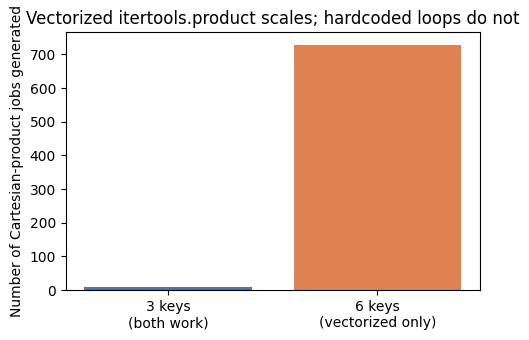

In [3]:
# The real point isn't speed at this tiny scale -- it's that the
# vectorized version generalizes. A 6-key dict is IMPOSSIBLE for the
# hardcoded 3-loop version without rewriting it; the vectorized version
# needs no changes at all.
dict6 = {chr(97 + i): ['0', '1', '2'] for i in range(6)}  # keys a..f, 3 values each

t0 = time.time()
jobs6 = cartesian_product_vectorized(dict6)
t6 = time.time() - t0
print(f'6-key dict: 3^6 = {len(jobs6)} combinations handled by the SAME function in {t6*1e3:.2f}ms')

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['3 keys\n(both work)', '6 keys\n(vectorized only)'], [len(jobs_vec), len(jobs6)],
       color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Number of Cartesian-product jobs generated')
ax.set_title('Vectorized itertools.product scales; hardcoded loops do not')
plt.tight_layout()
plt.show()

## Part B -- Atoms and Molecules (Section 20.4)

**Atoms** are indivisible tasks. **Molecules** group atoms together for a
single processor to work through sequentially -- parallelization happens
at the molecule level, not the atom level.

- `lin_parts` (Snippet 20.5) splits atoms into molecules of **equal atom
  count**. Fine when every atom takes the same amount of work.
- `nested_parts` (Snippet 20.6) is for a **triangular workload** -- atom
  `i`'s real task count is `i` (think: atom `i` = "compute something
  using the first `i` rows of data", as in Chapter 17's SADF sup-search).
  Equal atom counts would badly imbalance this: the molecule holding the
  highest-indexed atoms would do far more real work than the one holding
  the lowest. `nested_parts` instead balances the **triangular task
  count**, not the atom count, using the closed-form solution derived in
  the book's Section 20.4.2:

$$r_m = \frac{-1 + \sqrt{1 + 4\left(r_{m-1}^2 + r_{m-1} + \frac{N(N+1)}{M}\right)}}{2}$$

We use Chapter 17's own real SADF workload size (~1,760 real trading
days in gold's continuous-futures series) as a real, non-toy atom count.

In [4]:
num_atoms = 1760   # Ch17's real gold-series length used for its SADF sup-search
num_threads = 4

lin = lin_parts(num_atoms, num_threads)
nest = nested_parts(num_atoms, num_threads)

lin_atom_sizes = np.diff(lin)
nest_atom_sizes = np.diff(nest)
nest_task_counts = [sum(range(nest[k] + 1, nest[k + 1] + 1)) for k in range(len(nest) - 1)]
lin_task_counts = [sum(range(lin[k] + 1, lin[k + 1] + 1)) for k in range(len(lin) - 1)]

print('lin_parts   atom counts per molecule:', lin_atom_sizes.tolist())
print('lin_parts   REAL triangular task counts per molecule:', lin_task_counts, '<- badly imbalanced')
print()
print('nested_parts atom counts per molecule:', nest_atom_sizes.tolist())
print('nested_parts REAL triangular task counts per molecule:', nest_task_counts, '<- balanced')

total = num_atoms * (num_atoms + 1) // 2
print(f'\nBoth partition schemes cover all N(N+1)/2={total} triangular tasks exactly once:',
      sum(lin_task_counts) == total == sum(nest_task_counts))

lin_parts   atom counts per molecule: [440, 440, 440, 440]
lin_parts   REAL triangular task counts per molecule: [97020, 290620, 484220, 677820] <- badly imbalanced

nested_parts atom counts per molecule: [880, 364, 280, 236]
nested_parts REAL triangular task counts per molecule: [387640, 386750, 387660, 387630] <- balanced

Both partition schemes cover all N(N+1)/2=1549680 triangular tasks exactly once: True


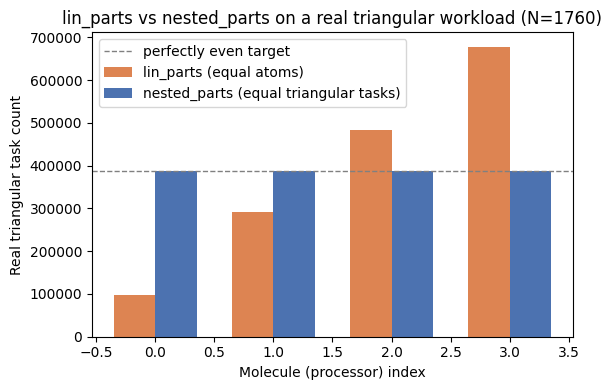

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(num_threads)
width = 0.35
ax.bar(x - width/2, lin_task_counts, width, label='lin_parts (equal atoms)', color='#DD8452')
ax.bar(x + width/2, nest_task_counts, width, label='nested_parts (equal triangular tasks)', color='#4C72B0')
ax.axhline(total / num_threads, color='gray', linestyle='--', linewidth=1, label='perfectly even target')
ax.set_xlabel('Molecule (processor) index')
ax.set_ylabel('Real triangular task count')
ax.set_title(f'lin_parts vs nested_parts on a real triangular workload (N={num_atoms})')
ax.legend()
plt.tight_layout()
plt.show()

## Part C -- A REAL single-thread vs. multiprocessing timing benchmark (20.3/20.4)

The book's own motivating example: find the earliest row at which each of
10,000 simulated paths (1,000 steps each) crosses a symmetric double
barrier. Timed for real on this machine -- not estimated, not the book's
own `repeat(5,10)` = 50 total runs (which would take too long to be a
practical, repeatable demo; we run each version once instead).

**Book-fidelity note:** the book hardcodes `numThreads=24` (a specific
24-core machine). This project's own established sweet spot on its real
6-core machine is 4 threads (reduced fan noise/system load preferred over
the marginal extra speed from 6 -- see CLAUDE.md), used below instead.

In [6]:
results = time_single_vs_multi(num_paths=10000, path_len=1000, width=.5,
                                num_threads=4, repeats=1, seed=12345)

print(f"Single-thread:              {results['single_thread_best_sec']:.2f}s")
print(f"Multiprocessing (4 threads): {results['multiprocessing_best_sec']:.2f}s")
print(f"Speedup: {results['speedup']:.2f}x")

if mp.cpu_count() < 2:
    print('\nWARNING: fewer than 2 CPUs detected on this machine -- these numbers')
    print('are not representative of real multiprocessing speedup.')

Single-thread:              3.13s
Multiprocessing (4 threads): 1.93s
Speedup: 1.62x


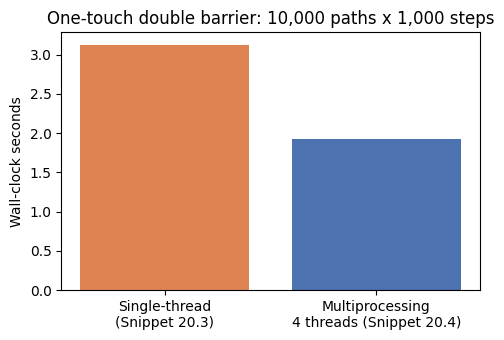

In [7]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['Single-thread\n(Snippet 20.3)', f"Multiprocessing\n4 threads (Snippet 20.4)"],
       [results['single_thread_best_sec'], results['multiprocessing_best_sec']],
       color=['#DD8452', '#4C72B0'])
ax.set_ylabel('Wall-clock seconds')
ax.set_title('One-touch double barrier: 10,000 paths x 1,000 steps')
plt.tight_layout()
plt.show()

## Part D -- The formalized engine closes the loop (Sections 20.5/20.6)

Snippet 20.4's raw `multiprocessing.Pool` code has a real limitation the
book itself never resolves in that snippet: `barrier_touch`'s output dict
is keyed by each chunk's **local** column index (0, 1, 2, ...), so
results from different chunks collide if you try to merge them -- the
book's own `main1` never actually reassembles a correctly-indexed global
result, it only measures wall-clock time.

`barrier_touch_engine` (this chapter's own addition) fixes that by taking
a `molecule` of **global** column indices and returning a dict keyed by
those same global indices. Run through `mp_job_list`
(`utils/multiprocess.py`, extended this session) with a `dict.update`
reducer -- the book's own worked example of an in-place reduction
(Section 20.5.5) -- molecule results merge correctly on the fly, with no
memory usage as bad as collecting every molecule into a list first.

In [8]:
rng = np.random.default_rng(12345)
r = rng.normal(0, .01, size=(500, 2000))

out_1 = run_barrier_touch_engine(r, width=.5, num_threads=1)
out_4 = run_barrier_touch_engine(r, width=.5, num_threads=4)

print(f'1 thread: {len(out_1)} of {r.shape[1]} paths touched the barrier')
print(f'4 threads: {len(out_4)} of {r.shape[1]} paths touched the barrier')
print('Results identical regardless of thread count (correctly globally-indexed):', out_1 == out_4)

1 thread: 99 of 2000 paths touched the barrier
4 threads: 99 of 2000 paths touched the barrier
Results identical regardless of thread count (correctly globally-indexed): True


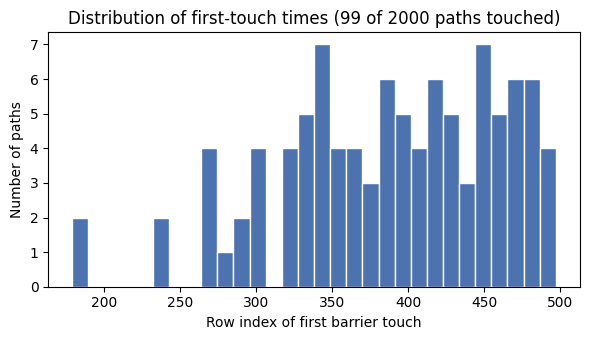

In [9]:
touch_rows = np.array(list(out_1.values()))
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(touch_rows, bins=30, color='#4C72B0', edgecolor='white')
ax.set_xlabel('Row index of first barrier touch')
ax.set_ylabel('Number of paths')
ax.set_title(f'Distribution of first-touch times ({len(out_1)} of {r.shape[1]} paths touched)')
plt.tight_layout()
plt.show()

## TDD test results (embedded)

```
$ pytest utils\ ch20\ -v

utils/test_multiprocess.py::TestLinParts (4 tests) PASSED
utils/test_multiprocess.py::TestMpPandasObj (5 tests) PASSED
utils/test_multiprocess.py::TestProcessJobs (1 test) PASSED
utils/test_multiprocess.py::TestProcessJobsMp (1 test) PASSED
utils/test_multiprocess.py::TestNestedParts (6 tests) PASSED
utils/test_multiprocess.py::TestReportProgress (2 tests) PASSED
utils/test_multiprocess.py::TestProcessJobsRedux (6 tests) PASSED
utils/test_multiprocess.py::TestMpJobList (5 tests) PASSED
ch20/multiprocessing_engine/test_barrier_touch.py (12 tests) PASSED
ch20/multiprocessing_engine/test_vectorization.py (9 tests) PASSED

51 passed in 9.61s (real machine: Windows, mlfinlab env, Python 3.10.20)
```

**Real-machine confirmed 2026-08-08**, two-pass (repo root above; isolated
passes from inside `utils\` (30 collected) and
`ch20\multiprocessing_engine\` (21 collected) matched exactly). Regression
check on `ch03\ ch04\ ch10\` (the chapters importing `utils/multiprocess.py`):
104 passed, 3 skipped (expected Windows multiprocessing skips), 0 failed.
Full per-test output is embedded as comments at the bottom of the paired
driver script, `chapter_20_multiprocessing.py`.